In [365]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [286]:
df = pd.read_csv("store_customers.csv")

In [287]:
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0


In [288]:
df.shape

(1000, 5)

In [289]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 40.3 KB


In [290]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [291]:
df["Gender"].unique()

<ArrowStringArray>
['M', 'F', nan]
Length: 3, dtype: str

In [292]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [293]:
(df.isnull().sum().sum() /len(df))*100

1.9

In [294]:
df["Gender"].mode()

0    F
Name: Gender, dtype: str

In [295]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [296]:
df["Gender"].isnull().sum()

0

<Axes: ylabel='Age'>

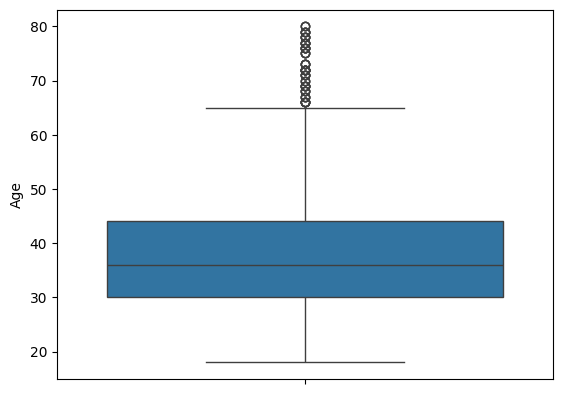

In [297]:
sns.boxplot(df["Age"])

In [298]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [299]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

### outlier remove

In [300]:
q1 = df["Age"].quantile(0.25)
q3 = df["Age"].quantile(0.75)

In [301]:
iqr = q3 -q1

In [302]:
lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr


In [303]:
df = df[(df["Age"] >= lower_limit) & (df["Age"] <= upper_limit)]

In [304]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

### after outlier remove from age columns

<Axes: ylabel='Age'>

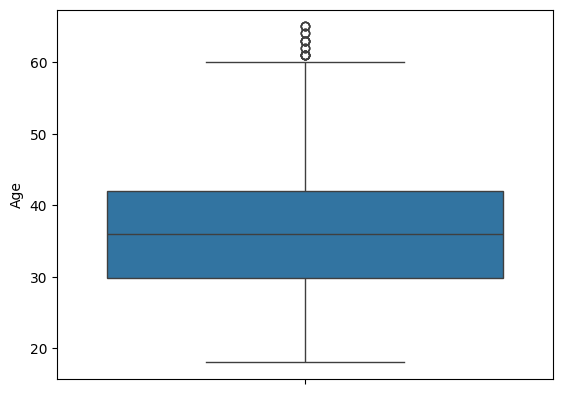

In [305]:
sns.boxplot(df["Age"])

In [306]:
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())

<Axes: ylabel='Annual Income (k$)'>

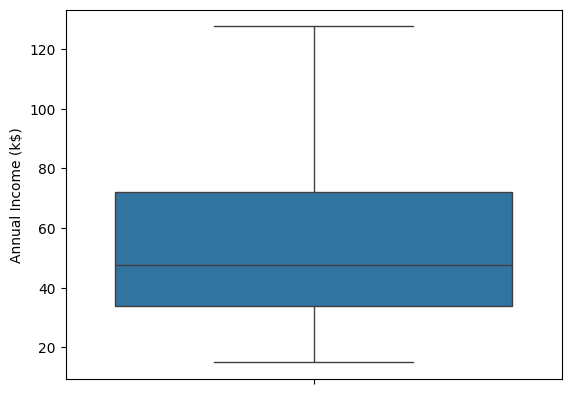

In [307]:
sns.boxplot(df["Annual Income (k$)"])

### remove outlier from spending score(1-1000)

In [308]:
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())

<Axes: ylabel='Spending Score (1-100)'>

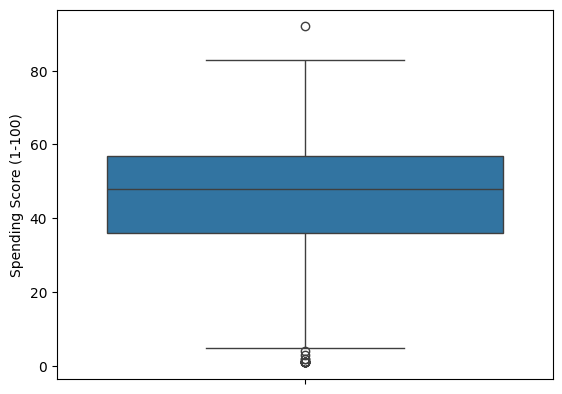

In [309]:
sns.boxplot(df["Spending Score (1-100)"])

### remove outlier from Spending Score (1-100)

In [310]:
q1 = df["Spending Score (1-100)"].quantile(0.25)
q3 = df["Spending Score (1-100)"].quantile(0.75)


In [311]:
iqr = q3-q1

In [312]:
lower_lt = q1 - 1.5*iqr
upper_lt = q3 + 1.5*iqr

In [313]:
df = df[(df["Spending Score (1-100)"] >= lower_lt ) & (df["Spending Score (1-100)"] <= upper_lt)]

### after outlier removal

<Axes: ylabel='Spending Score (1-100)'>

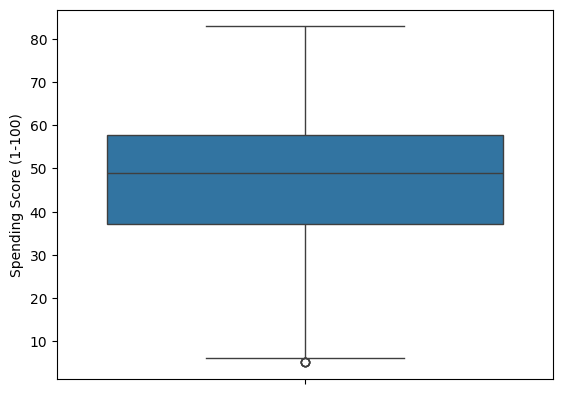

In [314]:
sns.boxplot(df["Spending Score (1-100)"])

In [315]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [316]:
df = df.drop("CustomerID",axis =1)

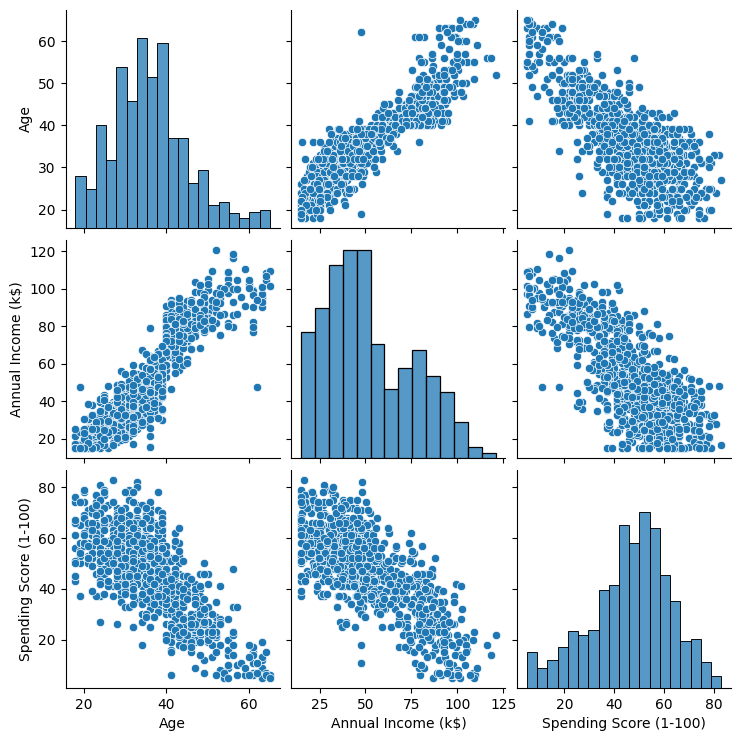

In [317]:
sns.pairplot(df)

### Data visulization

### 1). histogram

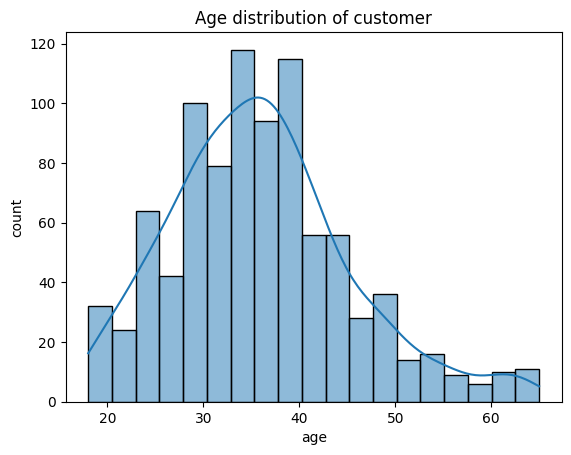

In [318]:
sns.histplot(df["Age"],kde = True)
plt.title("Age distribution of customer")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

### count plot 

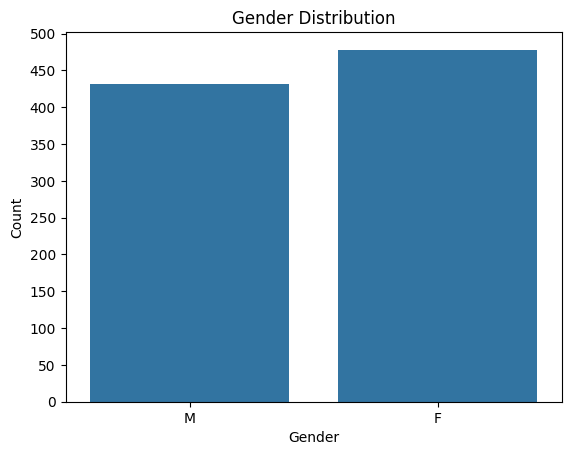

In [319]:
sns.countplot(x=df["Gender"])

plt.title("Gender Distribution")
plt.yticks(range(0,550,50))
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### 3) histplot

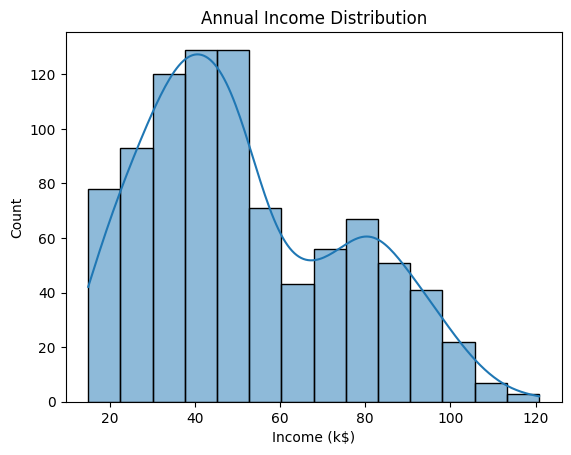

In [320]:
sns.histplot(df["Annual Income (k$)"], kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Income (k$)")
plt.ylabel("Count")

plt.show()

###  4).Scatter plot

In [321]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

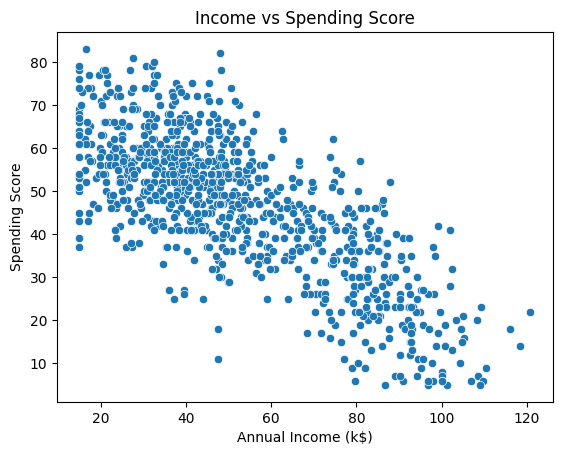

In [322]:
sns.scatterplot(x = df["Annual Income (k$)"] , y = df["Spending Score (1-100)"])
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

### scatter plot

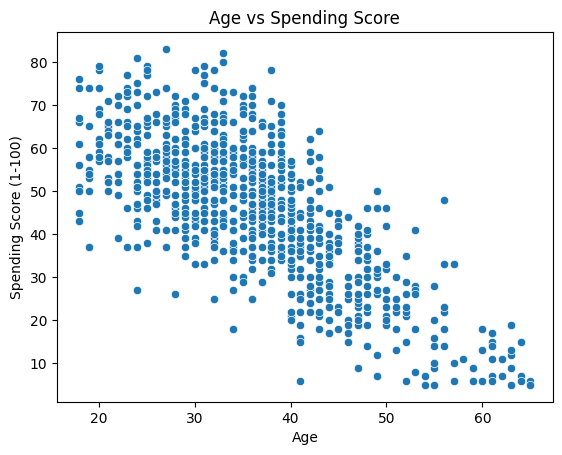

In [323]:
sns.scatterplot(
    x=df["Age"],
    y=df["Spending Score (1-100)"]
)

plt.title("Age vs Spending Score")
plt.show()

### heatmap

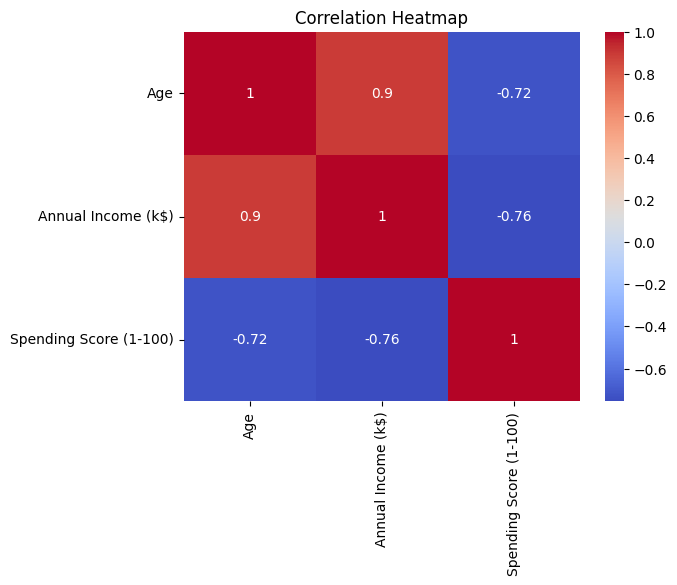

In [324]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

###  boxplot

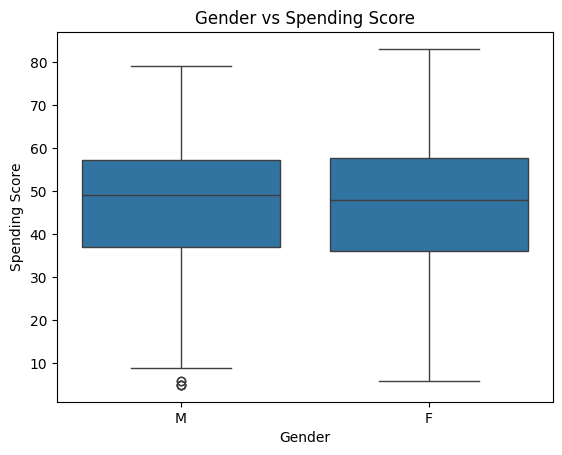

In [325]:

sns.boxplot(x=df["Gender"], y=df["Spending Score (1-100)"])

plt.title("Gender vs Spending Score")
plt.xlabel("Gender")
plt.ylabel("Spending Score")

plt.show()

### scatter plot

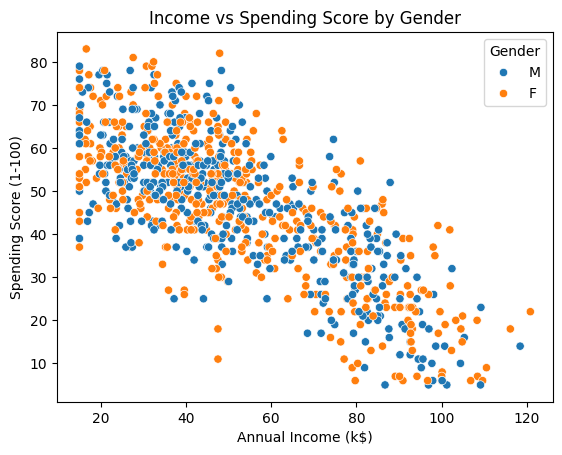

In [326]:
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Gender"]
)

plt.title("Income vs Spending Score by Gender")

plt.show()

In [327]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


In [328]:
df = df.drop(["Gender","Age"],axis = 1)

In [329]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


### Feature Selection

In [330]:
df.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [331]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

### scaling 

In [332]:
scaler = StandardScaler()

In [333]:
x_scaled = scaler.fit_transform(x)

In [334]:
x_scaled.mean()

-2.2448465552860307e-16

In [335]:
x_scaled.std()

1.0

### elbow method

In [336]:
WCSS = []
for i in range(2,21):
    km = KMeans(n_clusters=i,init="k-means++")
    km.fit(df)
    km.inertia_
    WCSS.append(km.inertia_)

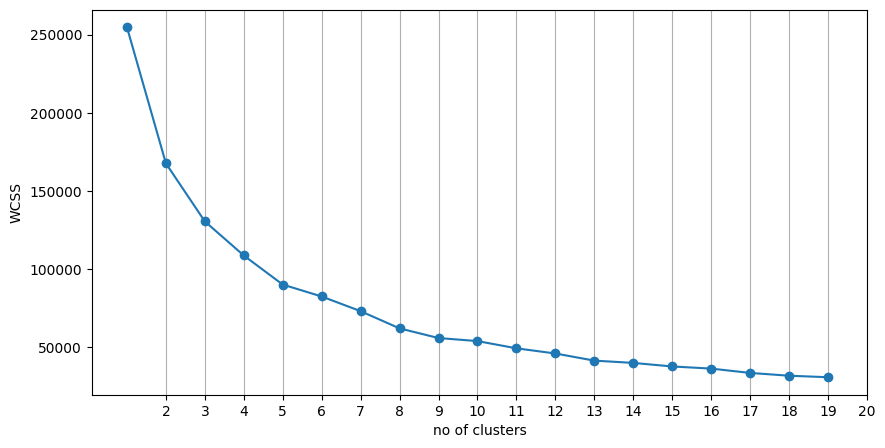

In [337]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(1,20)],WCSS, marker ="o")
plt.xlabel("no of clusters")
plt.xticks([i for i in range(2,21)])
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()

In [338]:
for i in range(2,11):
    km = KMeans(n_clusters=i, random_state=42)
    clusters = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled,clusters)
    print(i,score)

2 0.5410479382570084
3 0.40339191442218697
4 0.36063321726932007
5 0.33829446430077054
6 0.32013148403070024
7 0.3465400960562167
8 0.3367490942771713
9 0.3368905774328748
10 0.3269267425263575


In [339]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["cluster"] = kmeans.fit_predict(x_scaled)

In [342]:
df.head(3)

,Annual Income (k$),Spending Score (1-100),cluster
0,59.9,58.0,0
1,48.4,37.0,2
2,70.5,26.0,1


In [344]:
df["cluster"].unique()

array([0, 2, 1, 4, 3])

### visualization after k - means clustering 

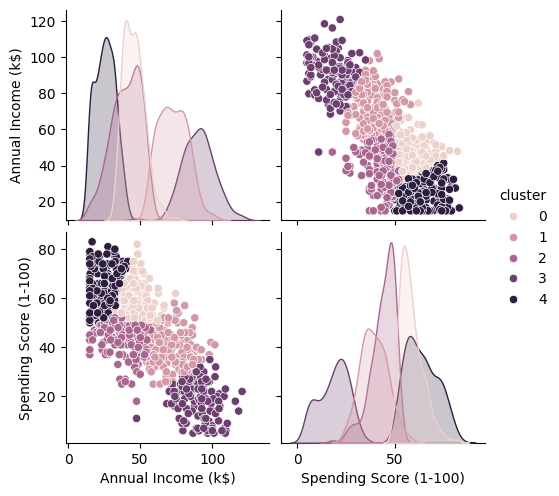

In [347]:
sns.pairplot(df, hue="cluster")

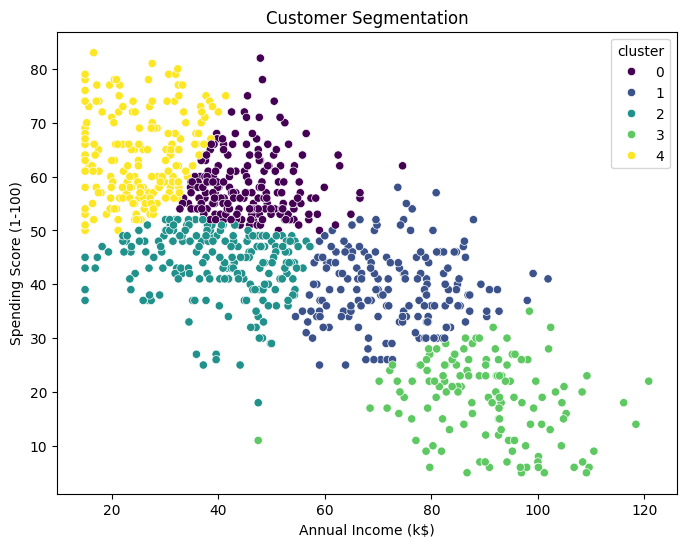

In [374]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("Customer Segmentation")

plt.savefig("cluster.png")   # pehle save
plt.show()                   # baad me show

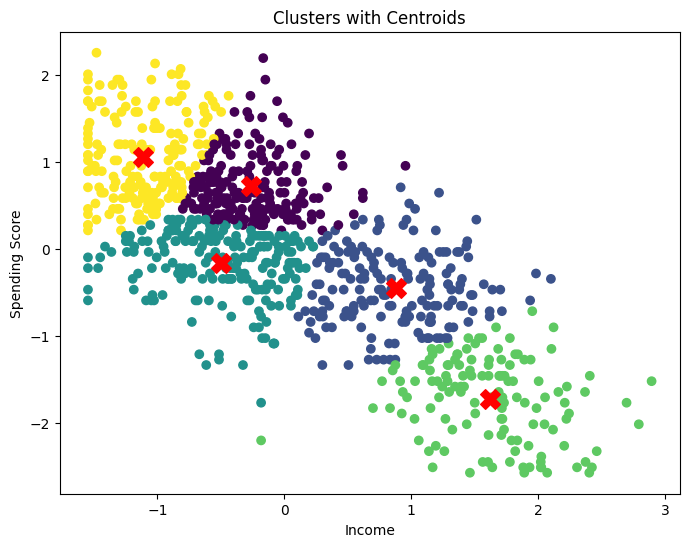

In [351]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=df["cluster"],
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="red",
    s=200,
    marker="X"
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Centroids")

plt.show()

Text(0.5, 1.0, 'customer per cluster')

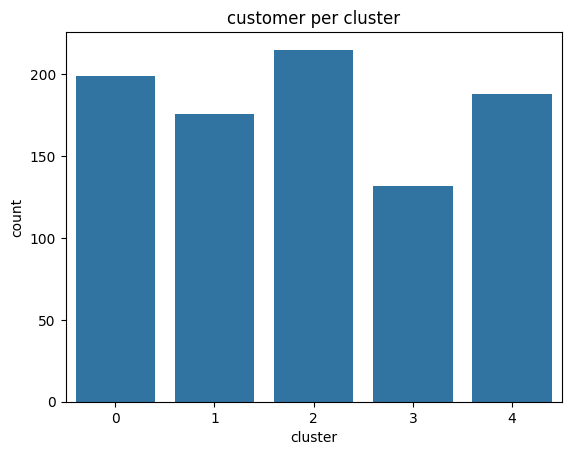

In [352]:
sns.countplot(x=df["cluster"])
plt.title("customer per cluster")

In [353]:
df.groupby("cluster").mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,45.557789,58.266332
1,72.767045,39.289773
2,40.033023,43.925581
3,90.401515,18.712121
4,25.481383,63.691489


### mapping customers

,Annual Income (k$),Spending Score (1-100),cluster
0,59.9,58.0,0
1,48.4,37.0,2
2,70.5,26.0,1
3,81.1,30.0,1
4,42.1,58.0,0


In [355]:
cluster_names = {
    0:"Careless Customer",
    1:"Standard Customer",
    2:"Target Customer",
    3:"Vip Customer",
    4:"Impulsive Customer"
}

In [357]:
df["Customer Segments"] = df["cluster"].map(cluster_names)

### prediction

In [366]:
new_customer = [[50,60]]

In [367]:
new_customer_scaled = scaler.transform(new_customer)

In [368]:
cluster = kmeans.predict(new_customer_scaled)

print(cluster)

[0]


In [369]:

segment = cluster_names[cluster[0]]

print(segment)

Careless Customer
